In [1]:
from google.colab import files
uploaded = files.upload()

Saving clean_email.csv to clean_email.csv


In [2]:
import pandas as pd
df = pd.read_csv("clean_email.csv")
df

,clean_text,Category,Urgency
0,anniversary special buy free loyal customer ex...,promotions,Low
1,amazon used new device refund processed claim ...,spam,Low
2,google inquiry following google application ra...,spam,Low
3,digital ritual experience creation cross cultu...,social_media,Low
4,post moved programming help trending cooking c...,forum,Low
...,...,...,...
7988,amazon used new device macbook air logged minu...,spam,Low
7989,john smith liked video great insight view noti...,social_media,Low
7990,reservation confirmed restaurant abc airline m...,updates,Low
7991,news mike chen started new position view profi...,social_media,Low


In [5]:
X = df['clean_text']
y = df['Category']

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 6394
Test size: 1599


In [11]:
#convert Text to Numbers (TF-IDF)
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=5000)
x_train_vector = vectorizer.fit_transform(X_train)
x_test_vector = vectorizer.transform(X_test)
print("x_train:",x_train_vector.shape)
print("x_test:",x_test_vector.shape)

x_train: (6394, 3128)
x_test: (1599, 3128)


In [18]:
from sklearn.linear_model import LogisticRegression

model1 = LogisticRegression(max_iter=200)
model1.fit(x_train_vector, y_train)

LogisticRegression(max_iter=200)

In [19]:
y_pred = model1.predict(x_test_vector)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9749843652282677
              precision    recall  f1-score   support

       forum       0.97      0.97      0.97       296
  promotions       1.00      0.95      0.97       222
social_media       0.95      0.98      0.97       301
        spam       0.98      0.98      0.98       278
     updates       0.98      0.98      0.98       295
 verify_code       0.98      1.00      0.99       207

    accuracy                           0.97      1599
   macro avg       0.98      0.98      0.98      1599
weighted avg       0.98      0.97      0.97      1599



In [20]:
#Naive Bayes
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(x_train_vector, y_train)

y_pred_nb = nb_model.predict(x_test_vector)

print("Accuracy:", accuracy_score(y_test, y_pred_nb))

Accuracy: 0.9687304565353346


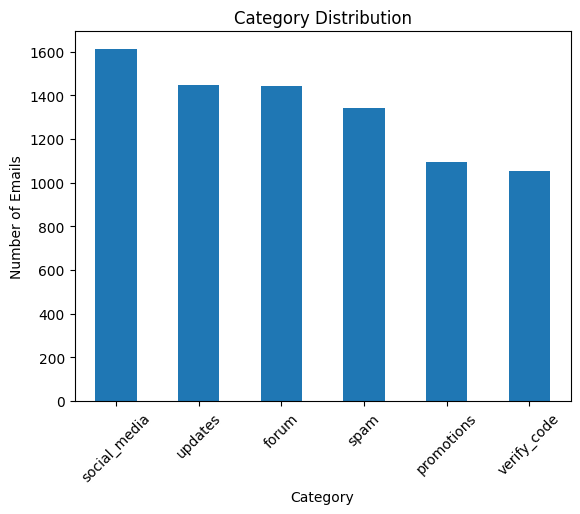

In [21]:
#Category Distribution Graph
import matplotlib.pyplot as plt

category_counts = df['Category'].value_counts()

plt.figure()
category_counts.plot(kind='bar')
plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Emails")
plt.xticks(rotation=45)
plt.show()

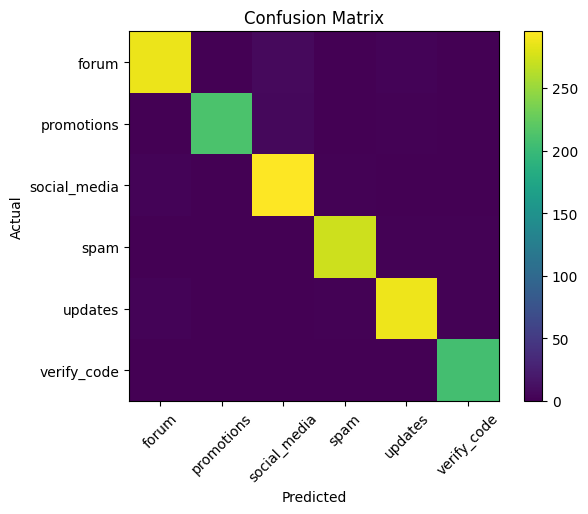

In [23]:
#Confusion Matrix Graph
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

labels = np.unique(y_test)
plt.xticks(range(len(labels)), labels, rotation=45)
plt.yticks(range(len(labels)), labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

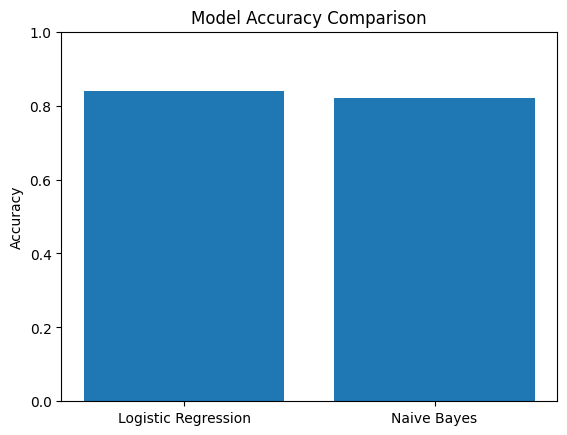

In [22]:
#Accuracy Graph
models = ['Logistic Regression', 'Naive Bayes']
accuracies = [0.84, 0.82]  # replace with your actual accuracy

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()